In [1]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import keras

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

print(f"Training set: {x_train.shape}")
print(f"Test set: {x_test.shape}")
print(f"Classes: {np.unique(y_train)}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training set: (60000, 28, 28)
Test set: (10000, 28, 28)
Classes: [0 1 2 3 4 5 6 7 8 9]


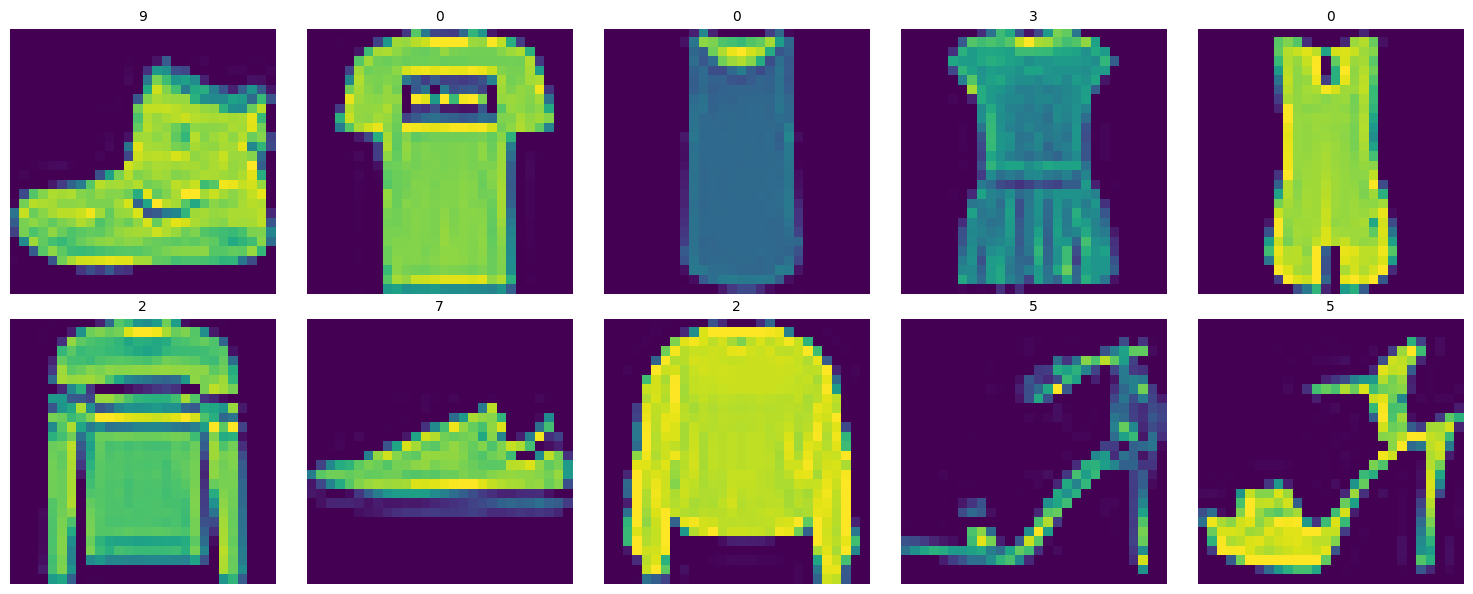

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(10):
    row, col = i // 5, i % 5
    axes[row, col].imshow(x_train[i])
    axes[row, col].set_title(f'{y_train[i]}', fontsize=10)
    axes[row, col].axis('off')
plt.tight_layout()
plt.show()

In [4]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print(f"Data range: [{x_train.min():.2f}, {x_train.max():.2f}]")

Data range: [0.00, 1.00]


In [6]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [7]:
model = keras.Sequential([
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Dropout(0.25),
    
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Dropout(0.25),
    
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Dropout(0.25),
    
    layers.GlobalAveragePooling2D(),
    
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.50),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.50),
    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 471,434 (1.80 MB)

 Trainable params: 470,538 (1.79 MB)

 Non-trainable params: 896 (3.50 KB)

In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3, weight_decay=1e-4),    
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        'best_fashion_mnist.keras',
        monitor='val_loss',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        mode='min',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        patience=3,
        factor=0.5,
        min_lr=1e-6,
        verbose=1
    )
]

In [10]:
model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=25,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/25
372/375 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5877 - loss: 1.1511
Epoch 1: val_loss improved from -inf to 8.92911, saving model to best_fashion_mnist.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.5891 - loss: 1.1472 - val_accuracy: 0.0957 - val_loss: 8.9291 - learning_rate: 0.0010
Epoch 2/25
371/375 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8427 - loss: 0.4555
Epoch 2: val_loss did not improve from 8.92911
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8428 - loss: 0.4552 - val_accuracy: 0.8192 - val_loss: 0.4545 - learning_rate: 0.0010
Epoch 3/25
373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8666 - loss: 0.3801
Epoch 3: val_loss did not improve from 8.92911
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8666 - loss: 0.3800 - val_accuracy: 0.8747 - val_loss: 0.3581 - learning_rate: 0.0010
Epoch 4/25
371/375 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8834 - loss: 0.3342
Epoch 4: val_loss did not improve from 8.

In [11]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9184 - loss: 0.2362
Accuracy: 0.9165
